In [11]:
# standard libraries
import os
import sys
import copy
import math
from pathlib import Path

# data manipulation
import pandas as pd
import numpy as np

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# statistics
from scipy import stats

# sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score

# notebook display
from IPython.display import display, HTML
import re

# correlations between categorical variables
from dython import nominal

# display settings
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", 250)

SEED = 42

REPO_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / ".git").exists())
DATA_DIR = REPO_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"

# 3. Exploratory Data Analysis (EDA)

In [12]:
data = pd.read_parquet(PROCESSED_DIR / "cleaned_eda_ready.parquet")

### 3.1 Non-Numeric Data Exploration



In [13]:
# identify categorical variables
categorical = data.select_dtypes(include=['object', 'category', 'string']).columns
print('There are {} categorical variables: {} \n'.format(len(categorical), list(categorical)))

There are 13 categorical variables: ['building', 'property_status', 'ownership', 'property_location', 'water', 'heating', 'gas', 'energy_performance_rating', 'waste', 'street', 'district', 'cadastral_area', 'layout'] 



##### 3.1.1 Missing Values in Categorical Columns

In [14]:
# calculate percentage of missing values
cat_missing = data[categorical].isna().mean() * 100

# display columns with missing values
missing_cats = cat_missing[cat_missing > 0].sort_values(ascending=False)
if not missing_cats.empty:
    print("Categorical columns with missing values (%):")
    display(missing_cats.to_frame("Missing %"))
else:
    print("No missing values found in categorical variables.")


Categorical columns with missing values (%):


,Missing %
gas,75.034965
water,54.662005
waste,49.230769
energy_performance_rating,18.578089
ownership,8.321678
building,8.321678
property_status,8.321678
street,3.752914
property_location,1.398601
cadastral_area,1.305361


##### 3.1.2 Explore Categorical Variables

In [ ]:
exclude_columns = ['location', 'street', 'cadastral_area']

for var in categorical:
    if var in exclude_columns:
        continue  # skip identifiers

    # frequency and percentage
    value_counts = data[var].value_counts(dropna=False)
    value_perc = (value_counts / len(data) * 100).round(2)

    summary = pd.concat([value_counts, value_perc], axis=1, keys=['Count', 'Percentage'])
    print(f"\n {var}: {data[var].nunique()} unique values:")
    display(HTML(summary.to_html()))

##### 3.1.3 Correlation Analysis for Categorical Variables.


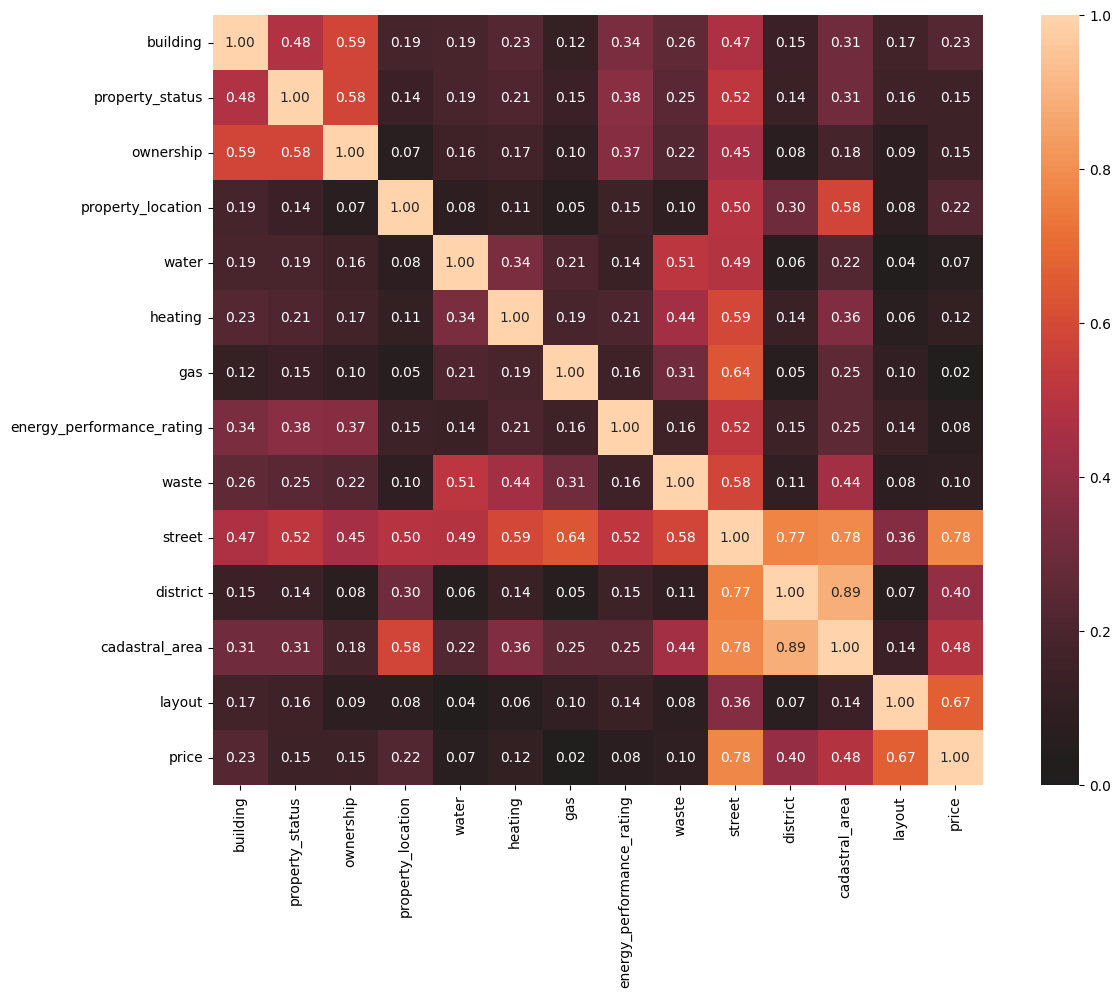

price                        1.000000
street                       0.779754
layout                       0.667226
cadastral_area               0.484804
district                     0.401993
building                     0.226889
property_location            0.222617
property_status              0.154704
ownership                    0.149665
heating                      0.116555
waste                        0.100604
energy_performance_rating    0.076412
water                        0.066434
gas                          0.019686
Name: price, dtype: float64


In [16]:
# correlation for non-numeric variables
# copy dataset for categorical associations
data_corr = data.copy()

# changing missing values in categorical variables to 'Missing'
for var in categorical:
    data_corr[var] = data_corr[var].fillna('Missing')

target = 'price'
categorical = categorical.tolist()
cols = categorical + [target]

corr_nom = nominal.associations(data_corr[cols],figsize=(15,10))


# extract correlations with the target
category_correlations = corr_nom["corr"][target].sort_values(ascending=False)
print(category_correlations)


- street has strong correlation with price (0.78) but 1397 unique values. too high cardinality to use directly
- district and cadastral_area overlap heavily (~0.89 with each other), similar predictive power (0.40 vs 0.49), probably redundant to keep both
- gas, water, heating, waste. low correlation with price and lots of missing data, consider dropping
- energy_performance_rating is ordinal (A–G), needs numeric encoding but only after train/test split to avoid leakage



##### 3.1.4 Visualize Target by Categories

In [17]:
def var_boxplot(var, data, target, title, xrotate=0, show_freq_table=True):
    """
    Boxplot of target by categorical variable, ordered by median target value.
    """
    temp = data.copy()

    order = (
        temp.groupby(var)[target]
        .median()
        .sort_values(ascending=False)
        .index
    )

    plt.figure(figsize=(14, 7))
    sns.boxplot(
        x=var,
        y=target,
        data=temp,
        order=order,
        linewidth=1.5
    )

    plt.title(title, fontsize=16, weight='bold')
    plt.xlabel(var)
    plt.ylabel(target.capitalize())
    plt.xticks(rotation=xrotate)
    plt.tight_layout()
    plt.show()

    if show_freq_table:
        value_counts = pd.concat([
            temp[var].value_counts(),
            temp[var].value_counts(normalize=True).mul(100)
        ], axis=1, keys=['Count', 'Percentage'])

        print(f"\n{var}: {temp[var].nunique()} unique values")
        display(HTML(value_counts.to_html()))



def var_boxplot_top_n(
    var, data, target, title,
    top_n=None, bottom_n=None, min_count=0,
    xrotate=45
):
    """Boxplot for top or bottom N categories by target median."""
    temp = data.copy()

    # count observations per category
    counts = temp[var].value_counts()
    valid_categories = counts[counts >= min_count].index

    temp = temp[temp[var].isin(valid_categories)]

    group_medians = temp.groupby(var)[target].median()

    # determine which categories to include
    if top_n is not None:
        selected = group_medians.nlargest(top_n).index
    elif bottom_n is not None:
        selected = group_medians.nsmallest(bottom_n).index
    else:
        raise ValueError("Specify either top_n or bottom_n.")

    # group the rest under 'Other'
    temp[var + '_grouped'] = temp[var].where(temp[var].isin(selected), 'Other')

    # ordering for boxplot
    order = (
        temp.groupby(var + '_grouped')[target]
        .median()
        .sort_values(ascending=False)
        .index
    )

    plt.figure(figsize=(14, 7))
    sns.boxplot(
        x=var + '_grouped',
        y=target,
        data=temp,
        order=order,
        linewidth=1.5
    )
    plt.title(title, fontsize=15, weight='bold')
    plt.xticks(rotation=xrotate)
    plt.show()

For most categorical comparisons we'll use price per square meter instead of total price.
This helps reduce the dominant effect of apartment size and will make it easier to understand the effect of location, building quality, and ownership effects and so on.
Total price is still used where appropriate and remains the final modeling target.

In [18]:
data['price_per_m2'] = data['price'] / data['square_meters']

### Property Status

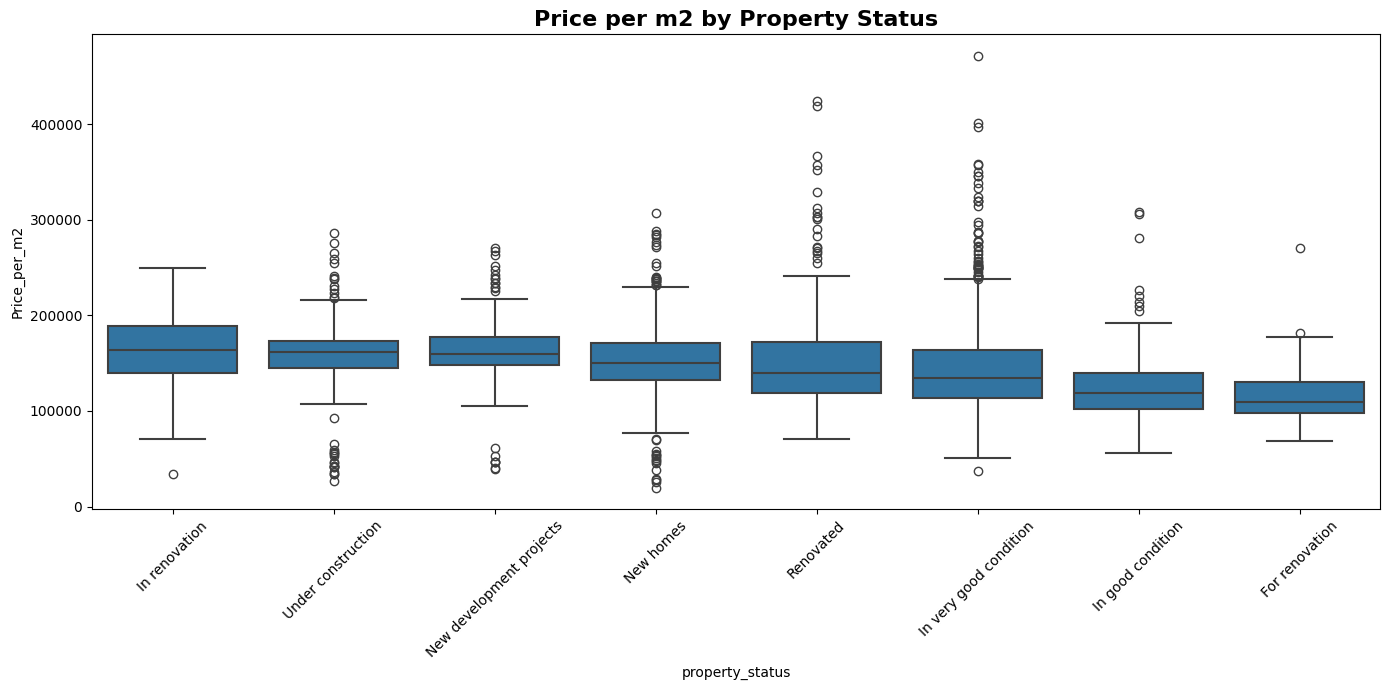


property_status: 8 unique values


,Count,Percentage
property_status,,
In very good condition,1299,33.028223
New homes,917,23.315535
Under construction,567,14.416476
Renovated,454,11.543351
In good condition,387,9.839817
New development projects,187,4.754640
For renovation,91,2.313755
In renovation,31,0.788202


In [19]:
var_boxplot(
    var='property_status',
    data=data,
    target='price_per_m2',
    title='Price per m2 by Property Status',
    xrotate=45
)

Apartments labeled as 'In renovation' show the highest median price per square meter. However, this category contains very few observations (only 31).

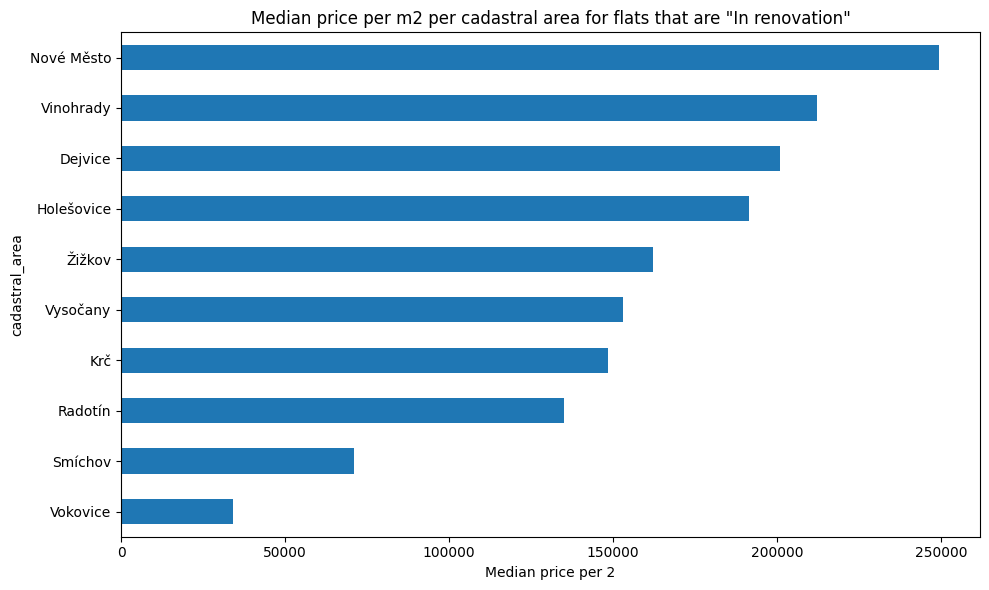

In [20]:
temp = data[data['property_status'] == 'In renovation'].copy()
group_medians = temp.groupby('cadastral_area')['price_per_m2'].median()
group_medians

group_medians.sort_values().plot(kind='barh', figsize=(10, 6))
plt.xlabel('Median price per 2')
plt.title('Median price per m2 per cadastral area for flats that are "In renovation"')
plt.tight_layout()
plt.show()

Apartments labeled as 'In renovation' are heavily concentrated in expensive central areas such as Nové Město, Vinohrady, and Dejvice and might include some premium and luxury flats.

A small number of very expensive properties in these locations strongly influences the distribution, making the median less representative. Because of that we should be careful when interpreting results for 'In renovation' category.

'Under construction' properties also show high prices, which is expected given their similarity to new homes in terms of quality and location.

### Property location

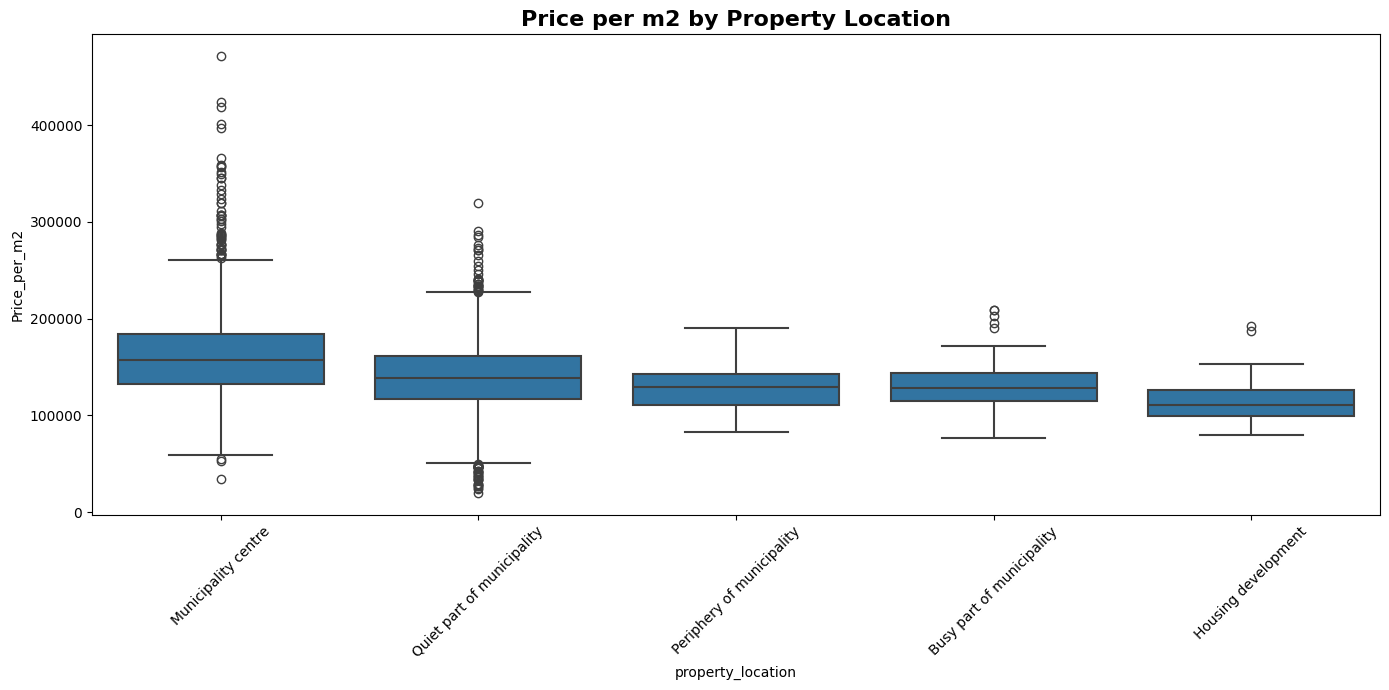


property_location: 5 unique values


,Count,Percentage
property_location,,
Quiet part of municipality,2608,61.654846
Municipality centre,1429,33.782506
Housing development,114,2.695035
Periphery of municipality,41,0.969267
Busy part of municipality,38,0.898345


In [21]:
var_boxplot(
    var='property_location',
    data=data,
    target='price_per_m2',
    title='Price per m2 by Property Location',
    xrotate=45
)


- properties located in the municipality center are the most expensive, which is expected.
- housing developments show the lowest median prices, despite often being newer buildings. But it's possible that housing development means something different in this classification, needs further investigation
- properties in busy parts of the municipality also tend to have lower prices.
- there're 2 very small categories - “Busy part of municipality” and “Periphery of municipality”, so their interpretation and analysis is limited.



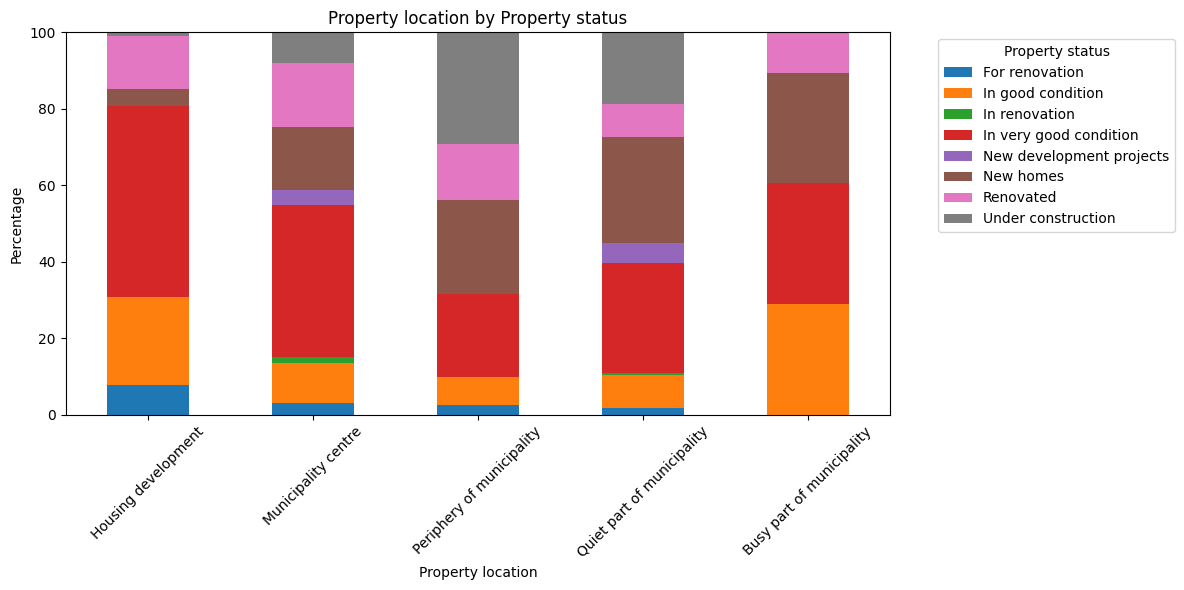

In [22]:
location_dist = (
    pd.crosstab(data['property_location'], data['property_status'], normalize='index').sort_values(by = 'New homes') * 100
).round(2)

pd.set_option('display.max_rows', 500)

location_dist.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6),
    color = sns.color_palette("tab10")
    )

plt.ylabel('Percentage')
plt.xlabel('Property location')
plt.xticks(rotation=45)
plt.title('Property location by Property status')
plt.legend(title='Property status', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

As we can see very small number of flats in 'Housing development' are actually new homes, in fact this category has the smallest share of new homes. It's not clear what housing development exactly means but it's clear that the label does not consistently correspond to modern developments and may include older apartments. Also it has high number of 'For renovation' and 'In good condition' properties, which are the cheapest based on the previous analysis.

As we can see, the only categories that give us reliable information and price difference are the 2 biggest categories - "Quiet part of municipality"	and
"Municipality centre". Other categories might be ambiguous in definition or too small to draw conclusions. So any analysis results that include this variable should be interpreted cautiously.

### Cadastral Area

Some cadastral areas contain very few observations in the dataset (for example Velká Chuchle has only 2 and it ends up with some of the highest median price). To avoid misleading conclusions we'll only include areas with at least five listings. The boxplot function was altered and now includes min_count parameter.

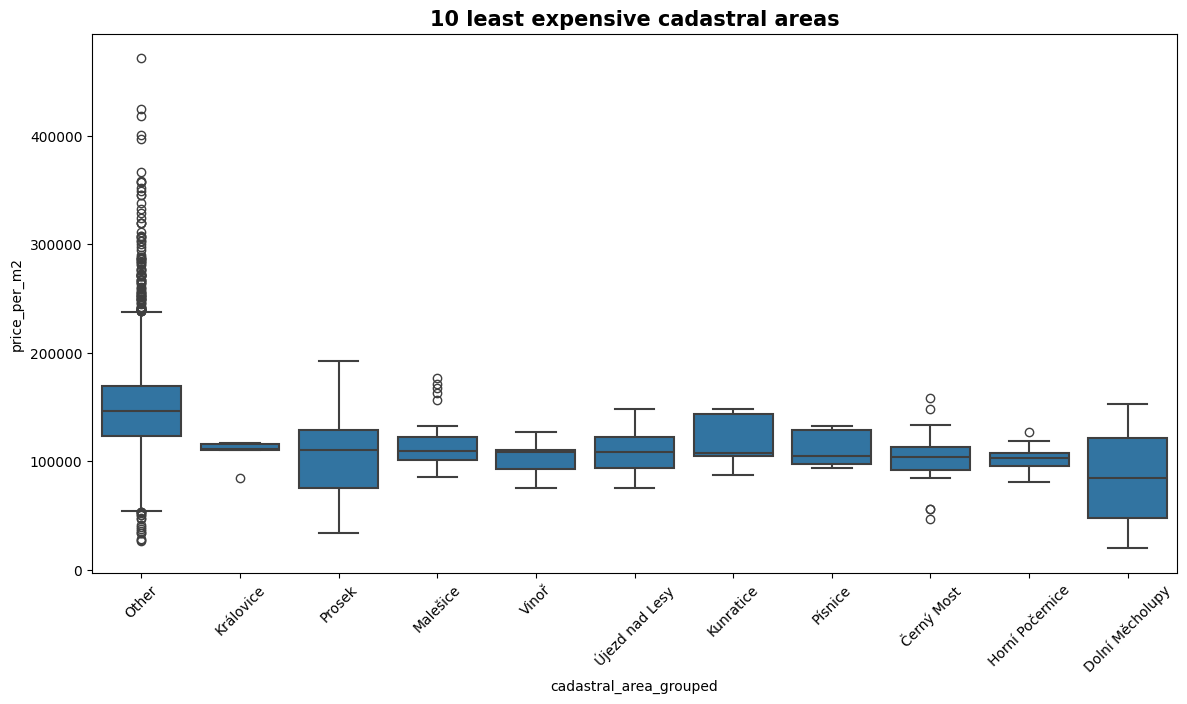

In [23]:
var_boxplot_top_n(
    var="cadastral_area",
    data=data,
    target="price_per_m2",
    bottom_n=10,
    min_count=5,
    title="10 least expensive cadastral areas"
)

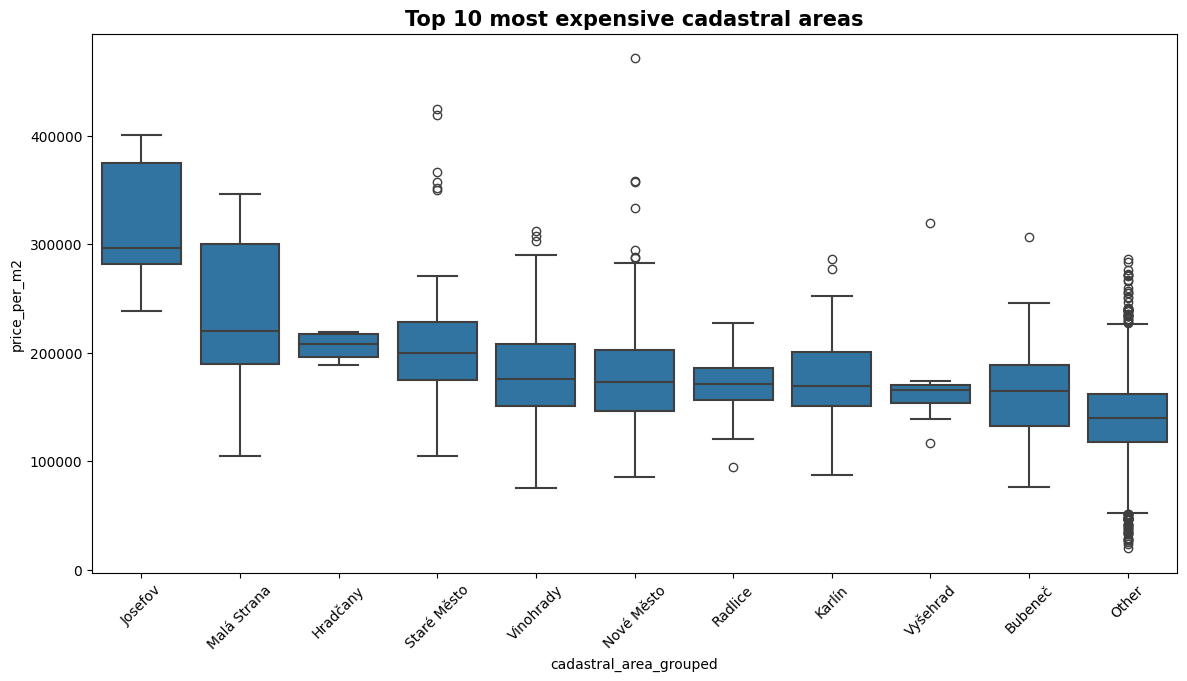

In [24]:
var_boxplot_top_n(
    var="cadastral_area",
    data=data,
    target="price_per_m2",
    top_n=10,
    min_count=5,
    title="Top 10 most expensive cadastral areas"
)

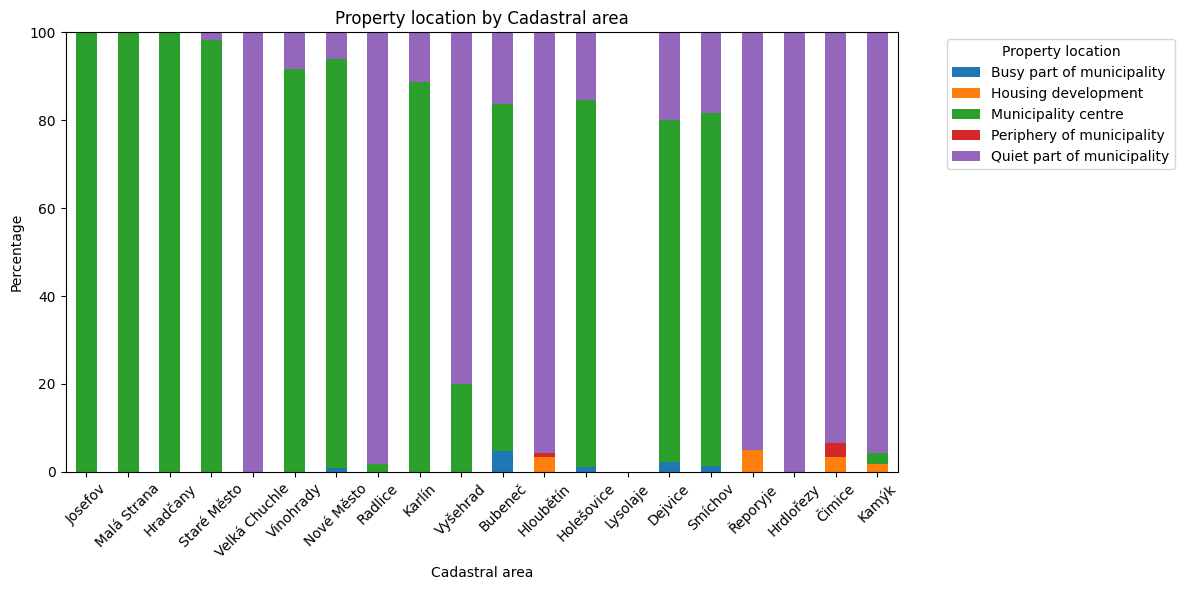

In [25]:
top_areas = (
    data.groupby('cadastral_area')['price_per_m2']
    .median()
    .nlargest(20)
    .index
)

data_top = data[data['cadastral_area'].isin(top_areas)]


district_dist = (
    pd.crosstab(data_top['cadastral_area'], data_top['property_location'], normalize='index').sort_values(by = 'Municipality centre', ascending = False) * 100).round(2).reindex(top_areas.tolist())
district_dist.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6),
    color = sns.color_palette()
)

plt.ylabel('Percentage')
plt.xlabel('Cadastral area')
plt.xticks(rotation=45)
plt.title('Property location by Cadastral area')
plt.legend(title='Property location', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

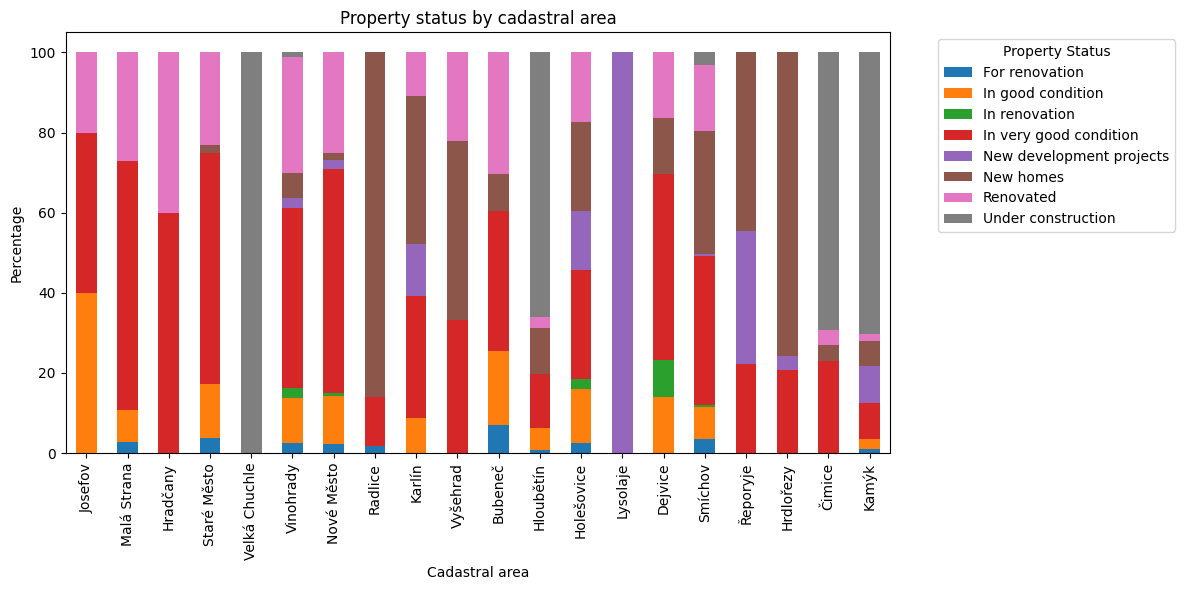

In [26]:
district_dist = (
    pd.crosstab(data_top['cadastral_area'], data_top['property_status'], normalize='index').sort_values(by = 'New homes', ascending = False) * 100).round(2).reindex(top_areas.tolist())
district_dist.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6),
    color = sns.color_palette()
)

plt.ylabel('Percentage')
plt.xlabel('Cadastral area')
plt.title('Property status by cadastral area')
plt.legend(title='Property Status', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

Some of the most expensive areas are in the historical areas in the city center. Those that are not in the center are usually located in the quiet parts of the city and have a large proportion of new homes (Radlice, Hrdlorezy), new development projects (Lysolaje), or under construction (Hloubetin, Cimice, Kamyk).

It seems that proximity to the center and amount of new development are the main factors driving price per m2 in any given area.

### District

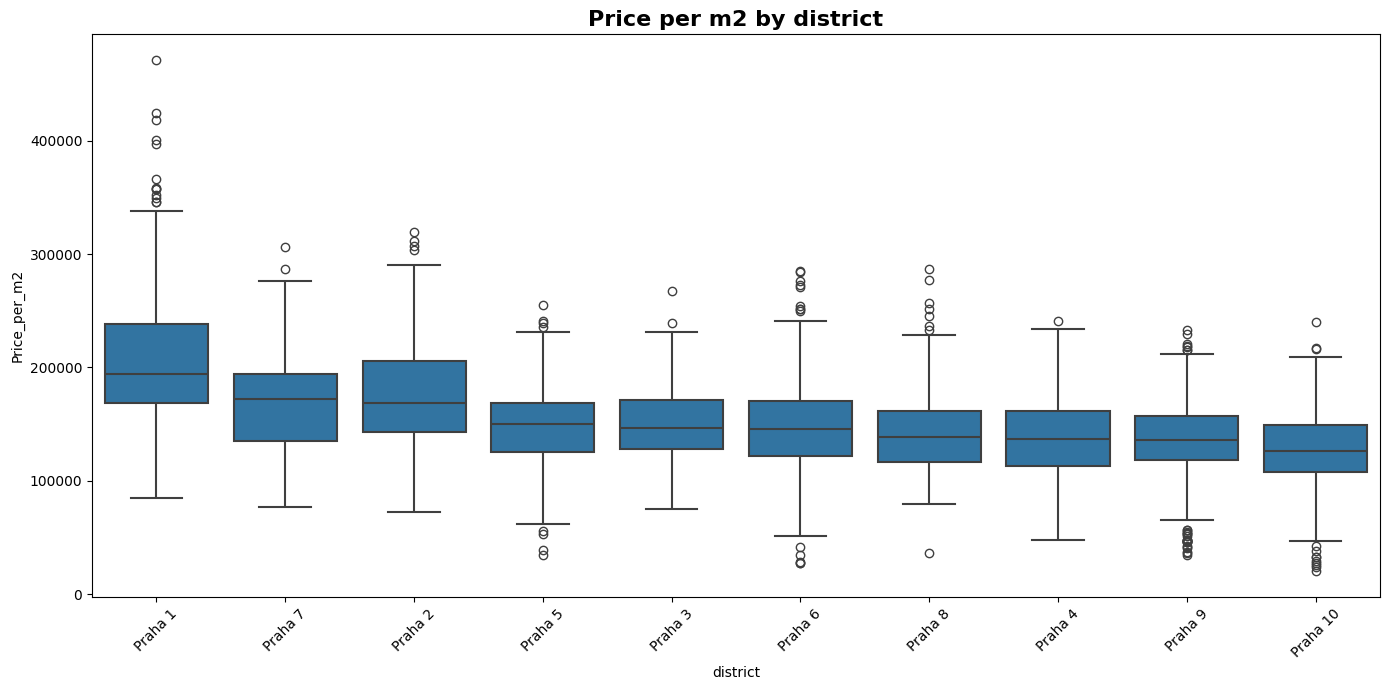


district: 10 unique values


,Count,Percentage
district,,
Praha 5,867,20.290194
Praha 9,785,18.371168
Praha 4,709,16.592558
Praha 10,470,10.999298
Praha 6,349,8.167564
Praha 3,310,7.254856
Praha 8,281,6.576176
Praha 1,201,4.703955
Praha 2,188,4.399719


In [27]:
var_boxplot(
    var='district',
    data=data,
    target="price_per_m2",
    title='Price per m2 by district',
    xrotate=45
)

Prague is now divided into 57 city districts, the division into 10 districts is outdated and it means that each district covers a very extensive and diverse area.

For example Prague 10 would cover the area from some of the most central and most expensive cadastral areas (part of Vinohrady belongs to Prague 10) to some of the most distant and cheapest ones (Dolní Měcholupy, the cheapest cadastral area, also belongs to Prague 10). Despite having a pretty good mix of new homes and flats in very good condition Praha 10 still remains the cheapest district.

Median price is very similar for quite a few areas, meaning that there's a big mix of new and old, central and peripheral areas in each district, making their medians pretty similar.

While it still has a pretty high association with price (although lower than cadastral_area) it seems that district alone might not be a very good price predictor, maybe it can be useful when paired with property status or some other metrics.

cadastral_area is more granular and slightly more correlated with price, but it has 100+ categories which creates too many coefficient estimates in linear models. district is a practical compromise. 10 categories, still reasonably predictive, much less overfitting risk.

### Layout

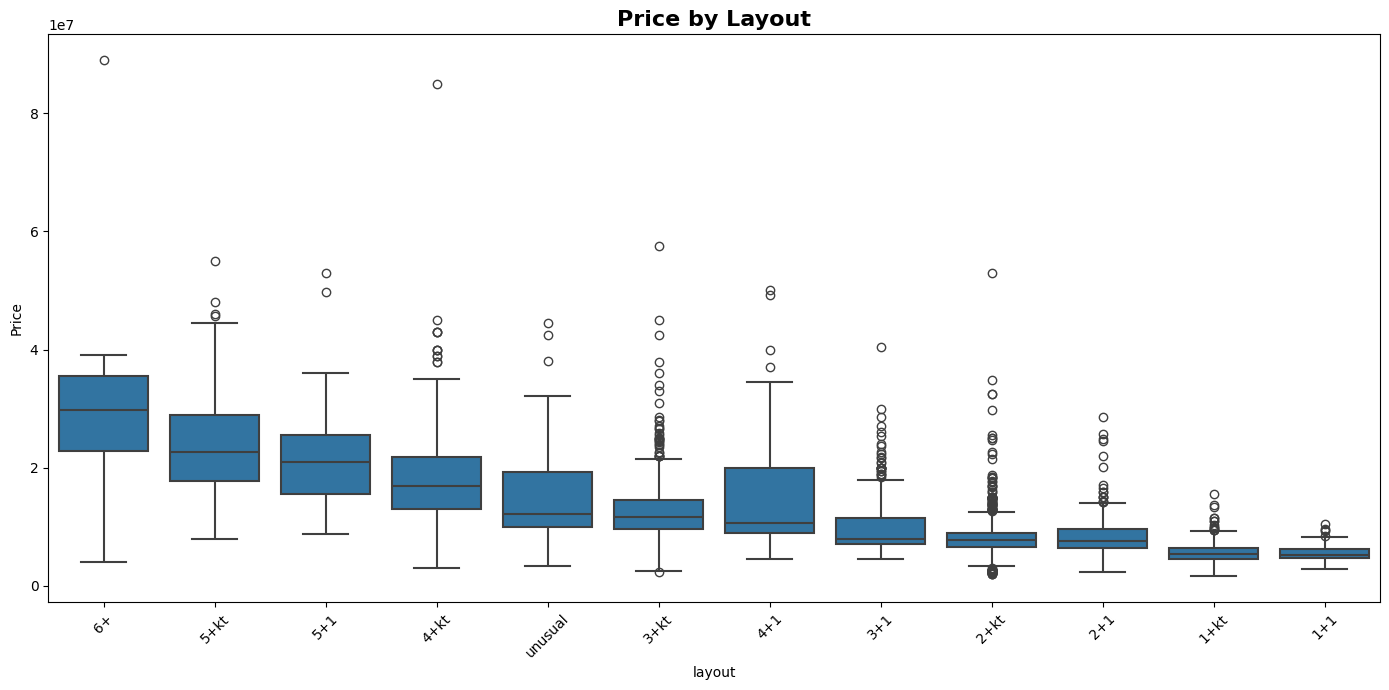


layout: 12 unique values


,Count,Percentage
layout,,
2+kt,1367,31.864802
3+kt,1038,24.195804
1+kt,554,12.913753
4+kt,422,9.836830
3+1,340,7.925408
2+1,243,5.664336
1+1,86,2.004662
4+1,84,1.958042
5+kt,80,1.864802


In [28]:
var_boxplot(
    var='layout',
    data=data,
    target=target,
    title='Price by Layout',
    xrotate=45
)

Layout is one of the strongest predictors for the price based on nominal association.
Surprisingly, layouts with a kitchenette (+kt) are consistently more expensive than layouts with +1.
For example, 1+kt apartments are priced higher than 1+1.

Possible explanation is that apartments with a kitchenette tend to be newer, better located, or have a modern design.

Overall, layout alone does not fully capture apartment size or quality, and modern compact layouts can be priced higher than larger but outdated ones.

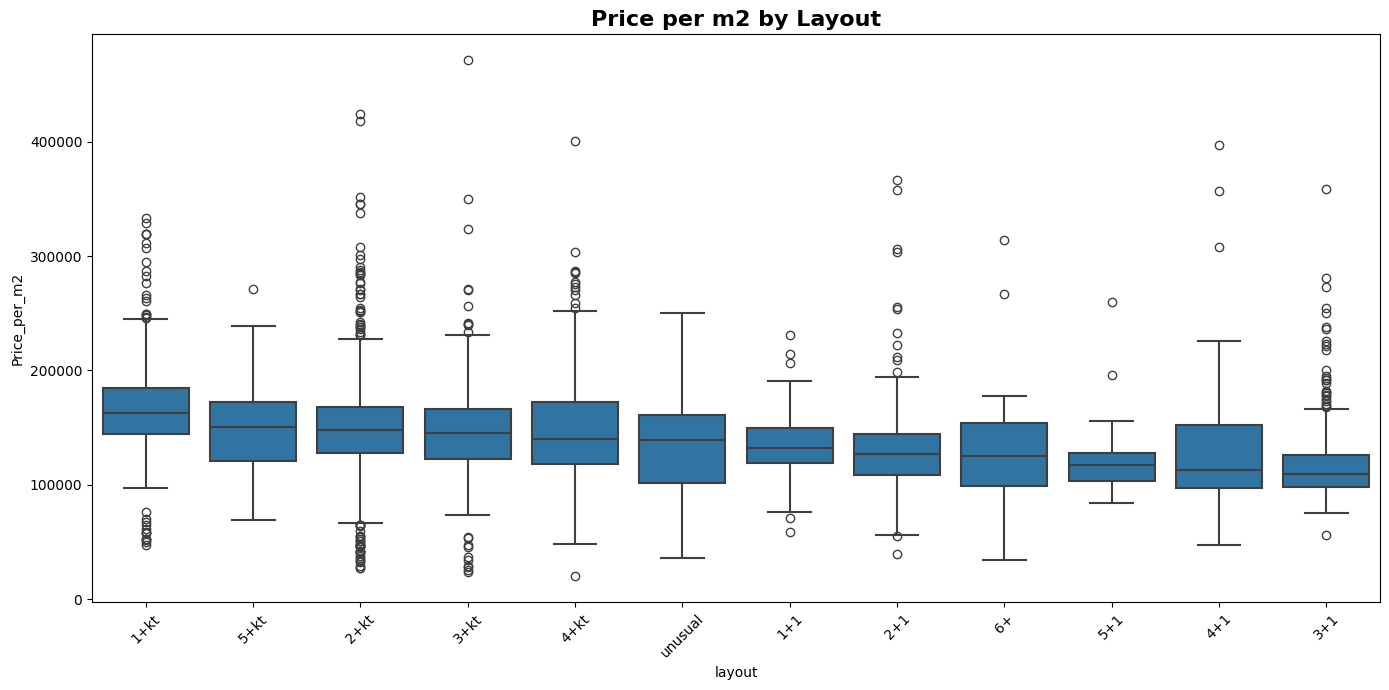


layout: 12 unique values


,Count,Percentage
layout,,
2+kt,1367,31.864802
3+kt,1038,24.195804
1+kt,554,12.913753
4+kt,422,9.836830
3+1,340,7.925408
2+1,243,5.664336
1+1,86,2.004662
4+1,84,1.958042
5+kt,80,1.864802


In [29]:
var_boxplot(
    var='layout',
    data=data,
    target='price_per_m2',
    title='Price per m2 by Layout',
    xrotate=45
)

Price per m2 is also more expensive for +kt flats, 1+kt being the most expensive.

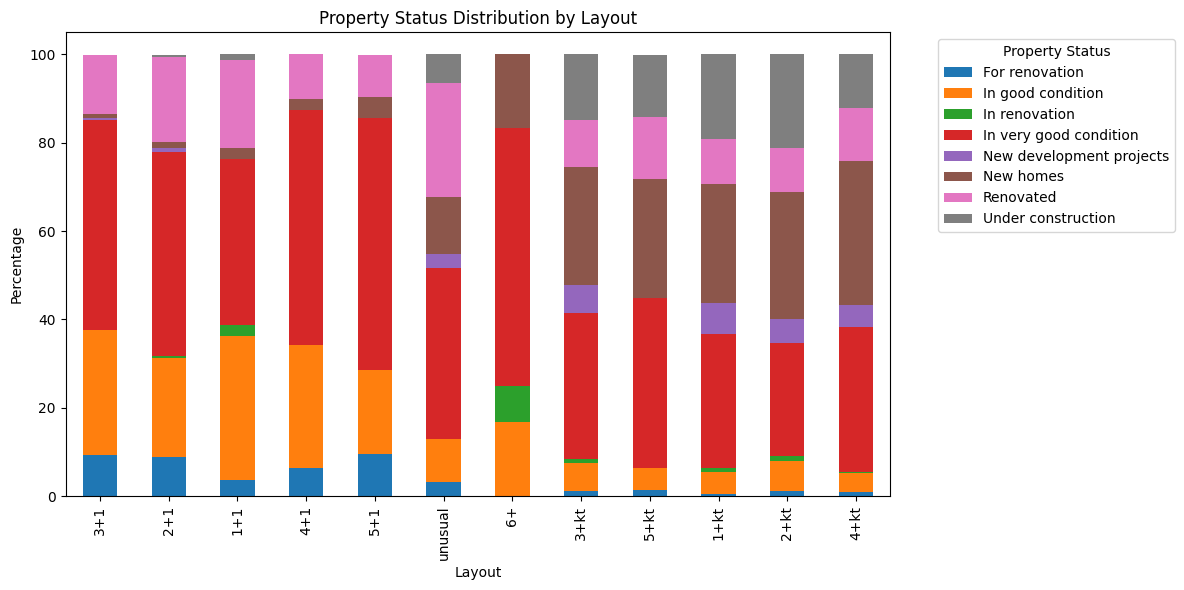

In [30]:
layout_dist = (
    pd.crosstab(data['layout'], data['property_status'], normalize='index').sort_values(by = 'New homes') * 100
).round(2)

layout_dist.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6)
)

plt.ylabel('Percentage')
plt.xlabel('Layout')
plt.title('Property Status Distribution by Layout')
plt.legend(title='Property Status', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

Crosstab analysis reveals that +kt layouts have a much higher share of new homes, new development projects and apartments under construction, while +1 layouts seem to be rarely found in the newer apartments.


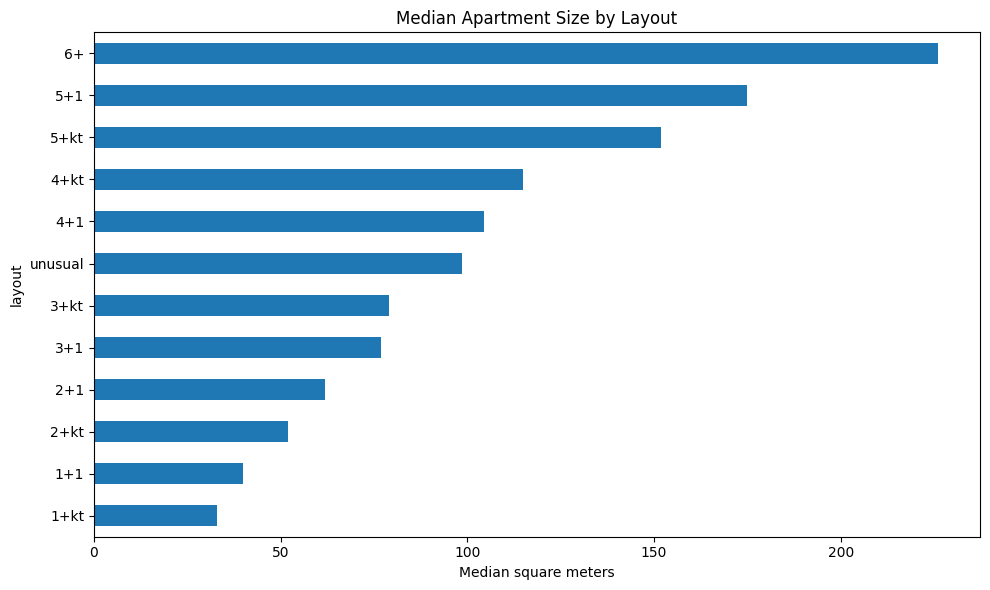

In [31]:
temp = data.copy()
group_medians = temp.groupby('layout')['square_meters'].median()

group_medians.sort_values().plot(kind='barh', figsize=(10, 6))
plt.xlabel('Median square meters')
plt.title('Median Apartment Size by Layout')
plt.tight_layout()
plt.show()

Layout analysis shows that apartments with a kitchenette are often smaller than +1, but still more expensive.

This suggests that higher prices of +kt apartments are rather driven by building age and quality but not necessarily the size.

### Ownership type

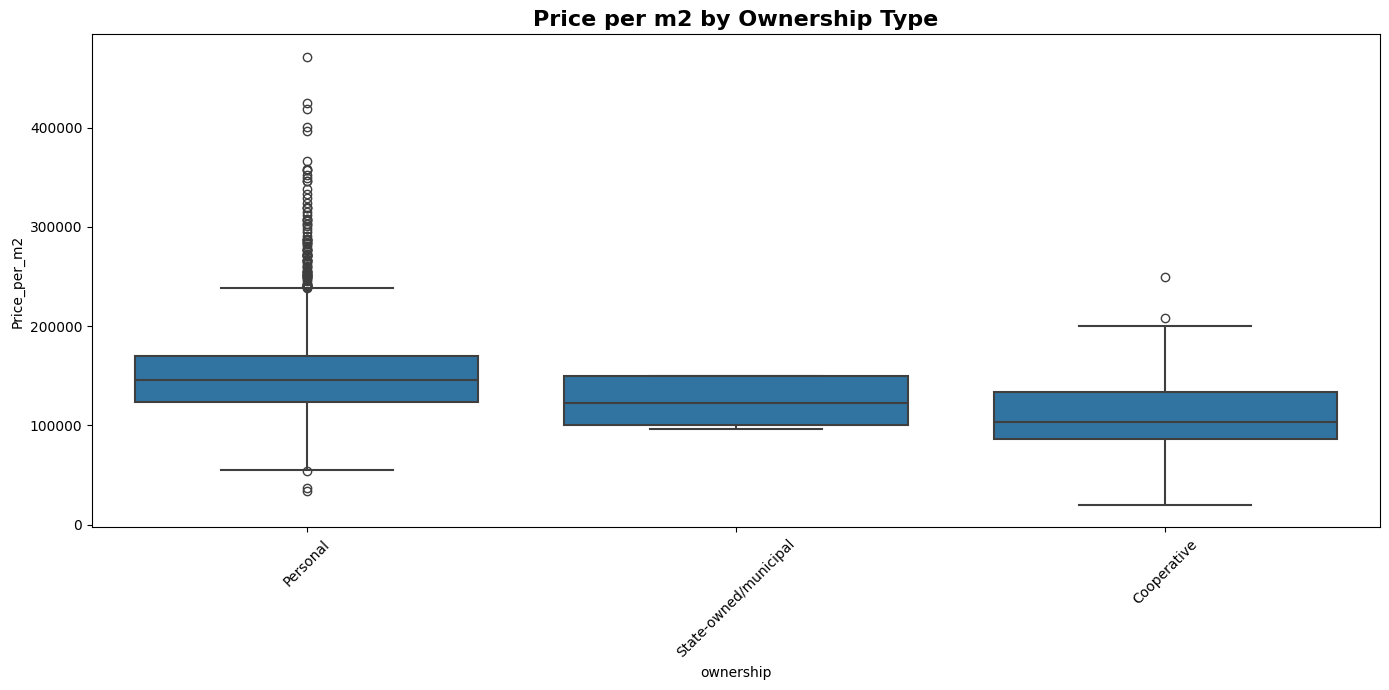


ownership: 3 unique values


,Count,Percentage
ownership,,
Personal,3681,93.592677
Cooperative,245,6.229341
State-owned/municipal,7,0.177981


In [32]:
var_boxplot(
    var='ownership',
    data=data,
    target='price_per_m2',
    title='Price per m2 by Ownership Type',
    xrotate=45
)

- state-owned properties represent a negligible fraction of the data (only 7 properties).

- cooperative ownership units are the cheapest but it's very likely that the price does not reflect the full price of the property, but only part of it as another part of the price may be payed in annuities or ongoing payments

Overall, ownership type is heavily imbalanced, one category represents 93% of properties while the rest is either has questionable values in our target (price is not full) or has a very minimal share (0.17%).

We should consider excluding this variable from modeling and probably also remove the cooperative flats due to not full values in the target.

### Building type

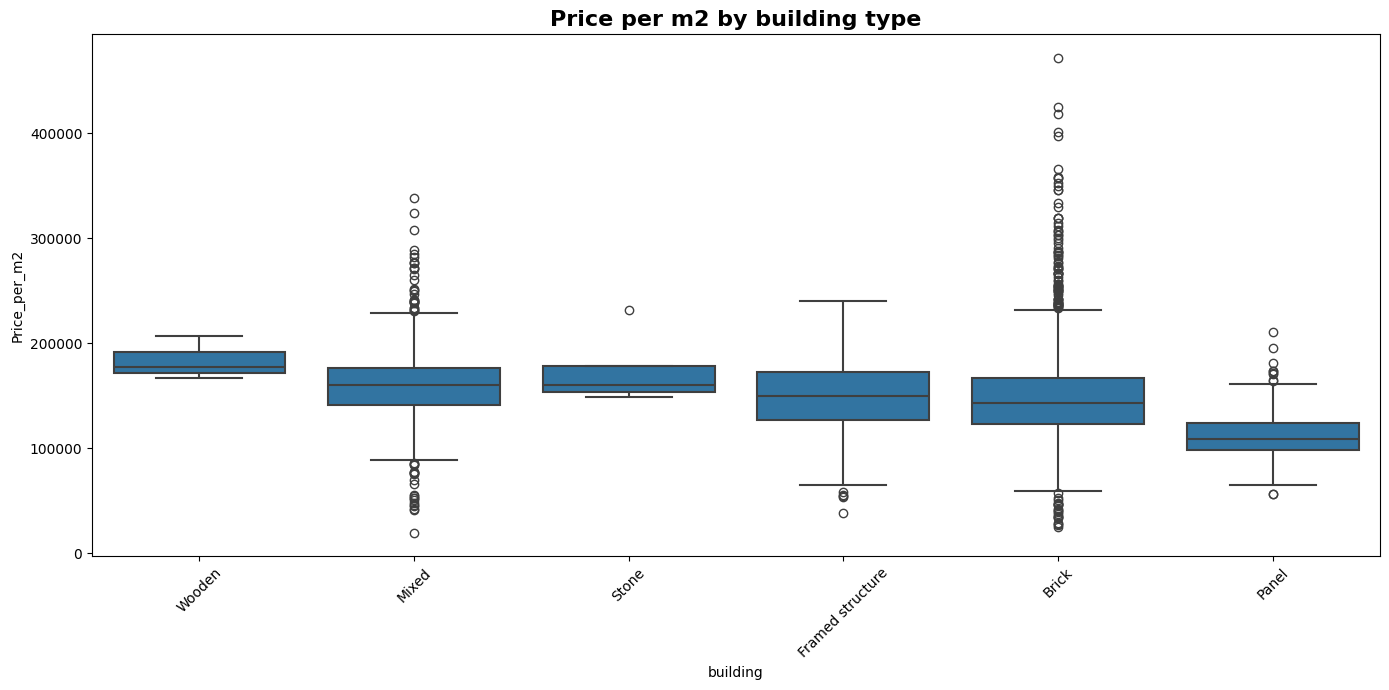


building: 6 unique values


,Count,Percentage
building,,
Brick,2089,53.114671
Mixed,1009,25.654717
Panel,542,13.780829
Framed structure,283,7.195525
Stone,7,0.177981
Wooden,3,0.076278


In [33]:
var_boxplot(
    var='building',
    data=data,
    target='price_per_m2',
    title='Price per m2 by building type',
    xrotate=45
)

- stone buildings show the highest median price, but they represent less than 1% of the dataset and likely reflect rare, historical or luxury buildings. So these results are not statistically reliable.

- panel buildings are the cheapest category, which most likely corresponds to the building complexes from socialist era.

- brick properties are the most common and even though they rank low in median price they have a lot of outliers in both directions.

Overall it seems that even though building type is a good price predictor, this variable alone is insufficient and most likely interaction with location, condition and age of the apartments is critical.

We'll most likely need to group rare categories for modeling.


- district used over cadastral_area. cadastral_area is more granular but 100+ categories is too high cardinality for linear models
- remove cooperative flats from dataset and don't use 'ownership_type' variable for modeling
- consider grouping rare categories in 'building', 'property_status' and 'property_location'

### 3.2 Numeric Data Exploration

3.2.1 Basic information


In [34]:
# identifying numerical variables
numerical = data.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f'Total numeric variables: {len(numerical)}')

# identifying discrete variables
levels_discrete = 30
discrete = [var for var in numerical if data[var].nunique() < levels_discrete]
print(f'Discrete variables: {discrete}')

# identifying continuous variables
continuous = [var for var in numerical if var not in discrete]
print(f'Continuous variables: {continuous}')

Total numeric variables: 18
Discrete variables: ['energy_performance_certificate', 'furnished', 'parking', 'garage', 'loggia', 'basin_area', 'floor_number', 'total_floors']
Continuous variables: ['price', 'usable_area', 'floorage', 'balcony', 'terrace', 'cellar', 'garden_area', 'final_building_approval_year', 'square_meters', 'price_per_m2']


In [35]:
# checking for missing values
num_miss = data[numerical].isnull().mean() * 100
print(num_miss[num_miss > 0].sort_values(ascending=False))

final_building_approval_year    67.202797
floorage                        41.048951
total_floors                    26.666667
usable_area                      8.321678
floor_number                     8.321678
dtype: float64


In [36]:
# summary stats
data[numerical].describe().T

,count,mean,std,min,25%,50%,75%,max
price,4290.0,10625406.47972,6479904.530725,1590000.0,6714457.75,8660849.0,12500000.0,89000000.0
usable_area,3933.0,74.100686,40.699205,10.0,49.0,66.0,88.0,537.0
floorage,2529.0,71.135231,34.945458,10.0,49.0,64.0,84.0,389.0
balcony,4290.0,1.439627,3.67104,0.0,0.0,0.0,0.0,55.0
energy_performance_certificate,4290.0,0.108159,0.310617,0.0,0.0,0.0,0.0,1.0
furnished,4290.0,0.176224,0.381055,0.0,0.0,0.0,0.0,1.0
terrace,4290.0,4.104429,14.748496,0.0,0.0,0.0,0.0,220.0
cellar,4290.0,1.246853,3.117336,0.0,0.0,0.0,2.0,100.0
parking,4290.0,0.200699,1.255828,0.0,0.0,0.0,0.0,40.0
garden_area,4290.0,8.625175,54.141717,0.0,0.0,0.0,0.0,1800.0


3.2.2 Visualizations

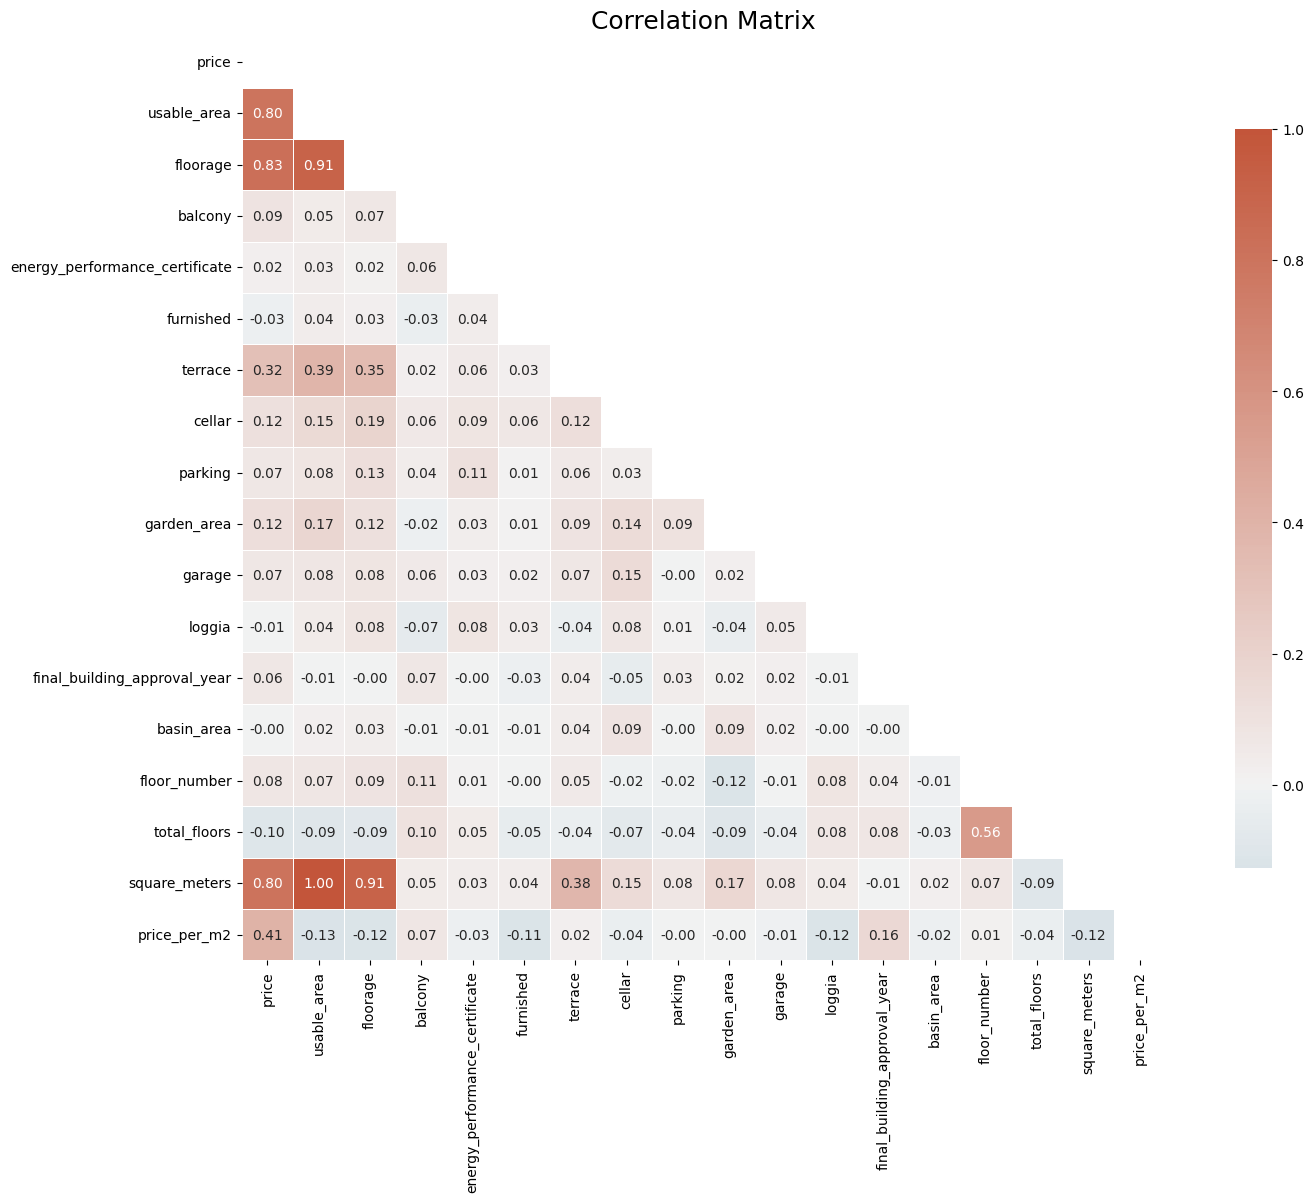

price                             1.000000
floorage                          0.829951
square_meters                     0.801898
usable_area                       0.801631
price_per_m2                      0.405386
terrace                           0.318346
garden_area                       0.122901
cellar                            0.115326
total_floors                     -0.101826
balcony                           0.091803
floor_number                      0.079658
garage                            0.071102
parking                           0.066113
final_building_approval_year      0.064863
furnished                        -0.027436
energy_performance_certificate    0.019291
loggia                           -0.007451
basin_area                       -0.000296
Name: price, dtype: float64


In [37]:
# correlation matrix
corr_matrix = data[numerical].corr()

# mask to hide upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(18, 12))
cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(corr_matrix, mask=mask, cmap=cmap, vmax=1, center=0, annot=True,
            fmt=".2f", square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})

plt.title("Correlation Matrix", fontsize=18)
plt.show()
num_corr = data[numerical].corr()['price'].sort_values(ascending = False, key = abs)
print(num_corr)

- price is highly correlated with square meters (0.80), floorage (0.83) and usable area (0.71), meaning larger properties tend to be more expensive.
- those 3 features are highly correlated between each other and probably carry the same information, we'll need to deal with it for linear modeling to prevent multicollinearity
- total_floors has negative correlation probably indicating that high rise buildings are usually  located outside of the city center and therefore are cheaper
- 'basin_area', 'loggia' have very low correlation with target and other variables, most likely because of the high number of missing values. Needs to be either dropped or NAs should be filled.
- 'terrace' has a good correlation with both 'price' and 'square_meters'

Feature: price


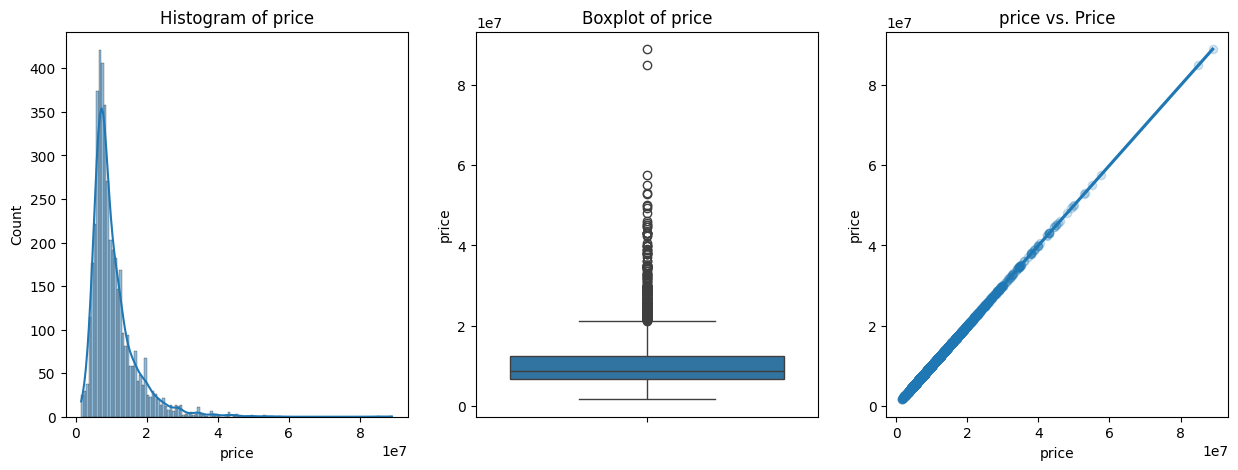

Feature: usable_area


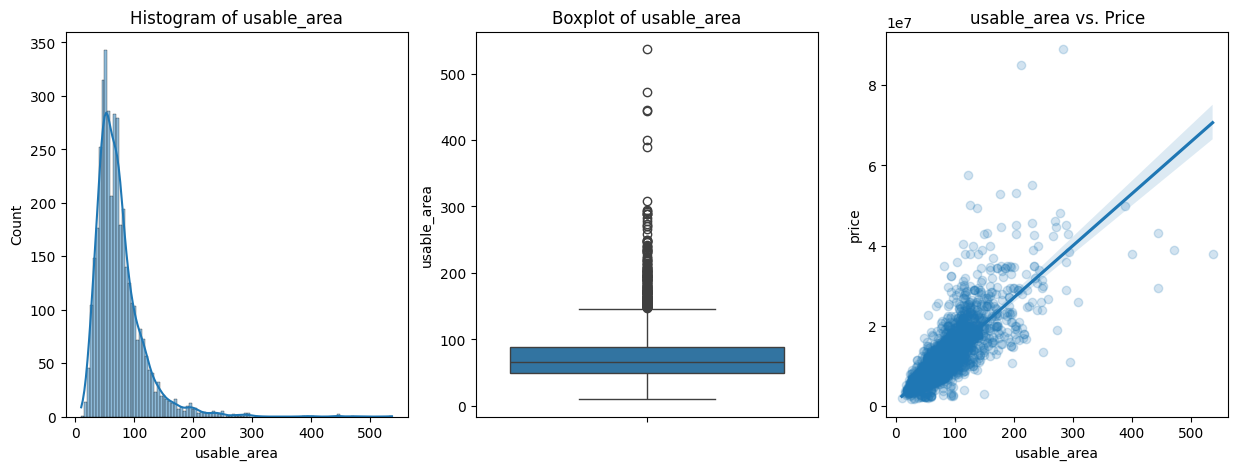

Feature: floorage


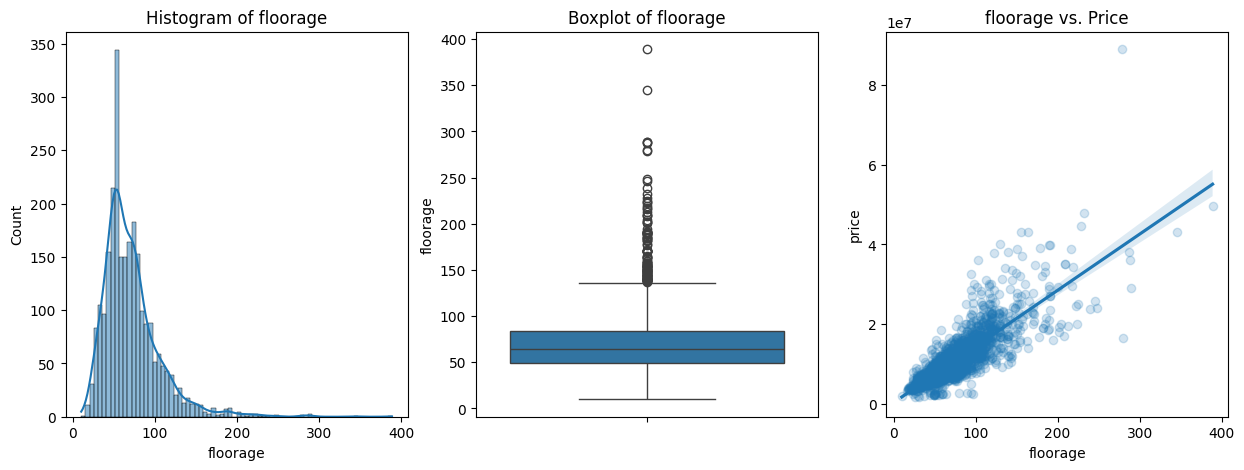

Feature: balcony


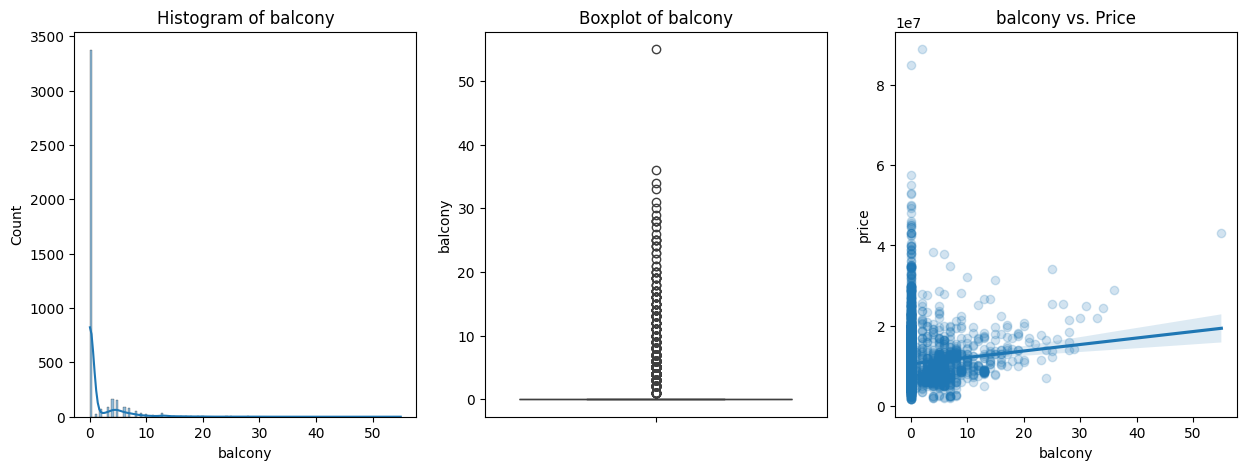

Feature: terrace


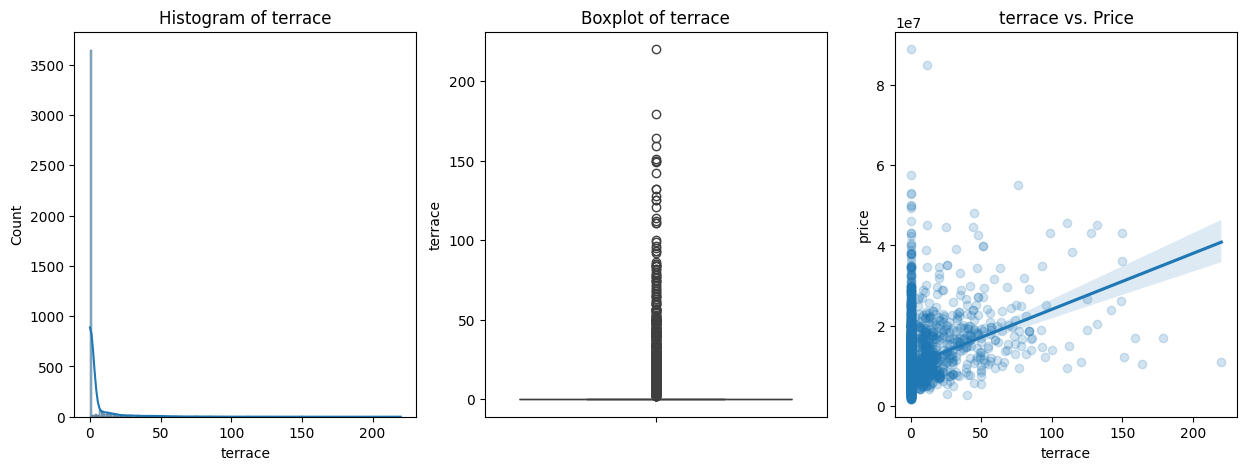

Feature: cellar


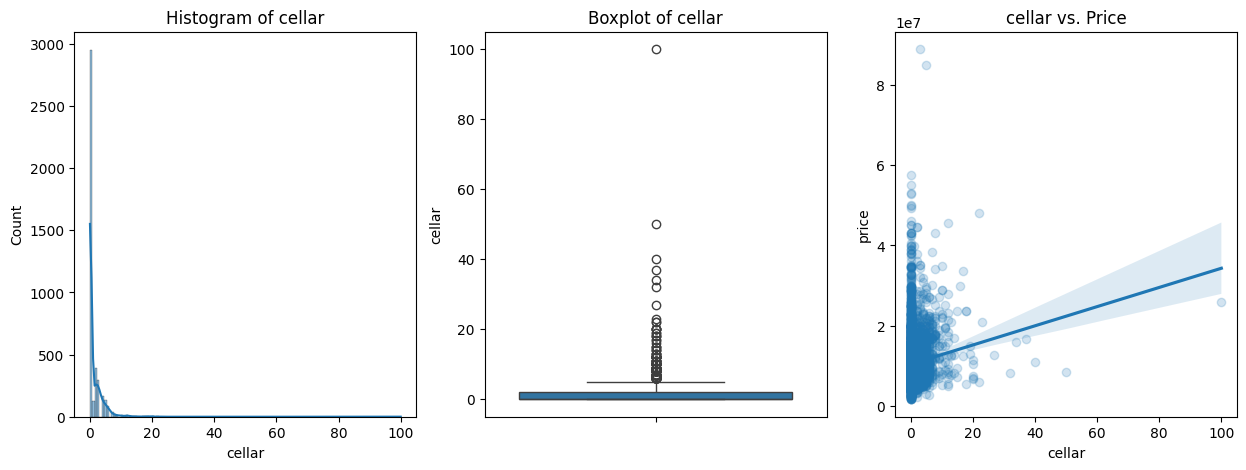

Feature: garden_area


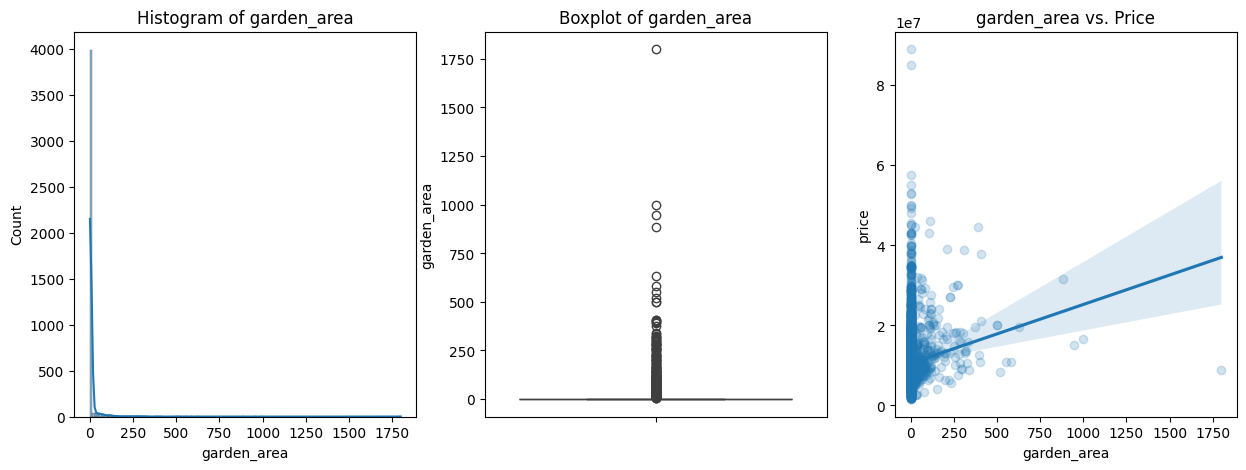

Feature: final_building_approval_year


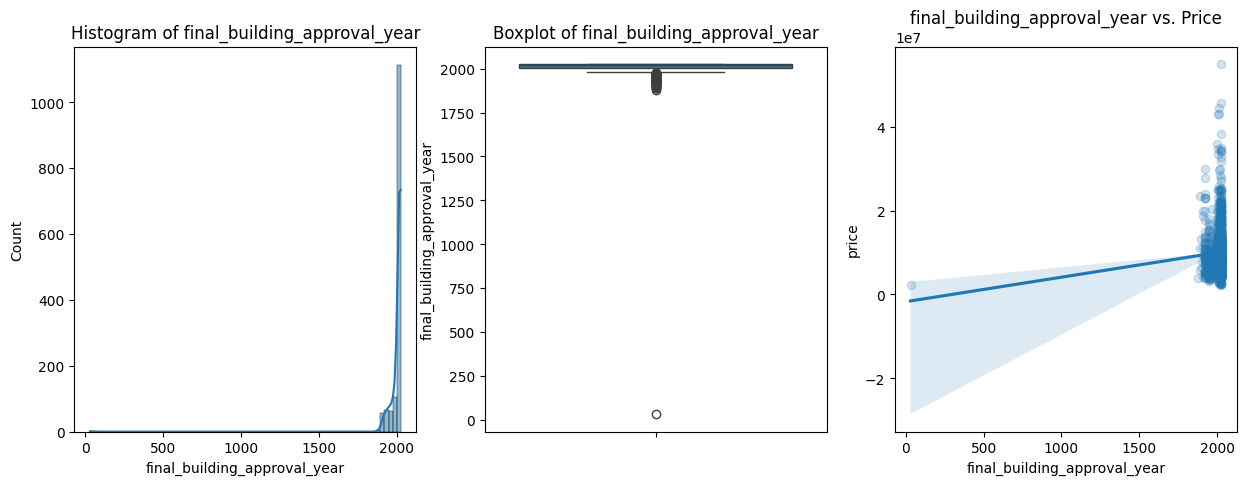

Feature: square_meters


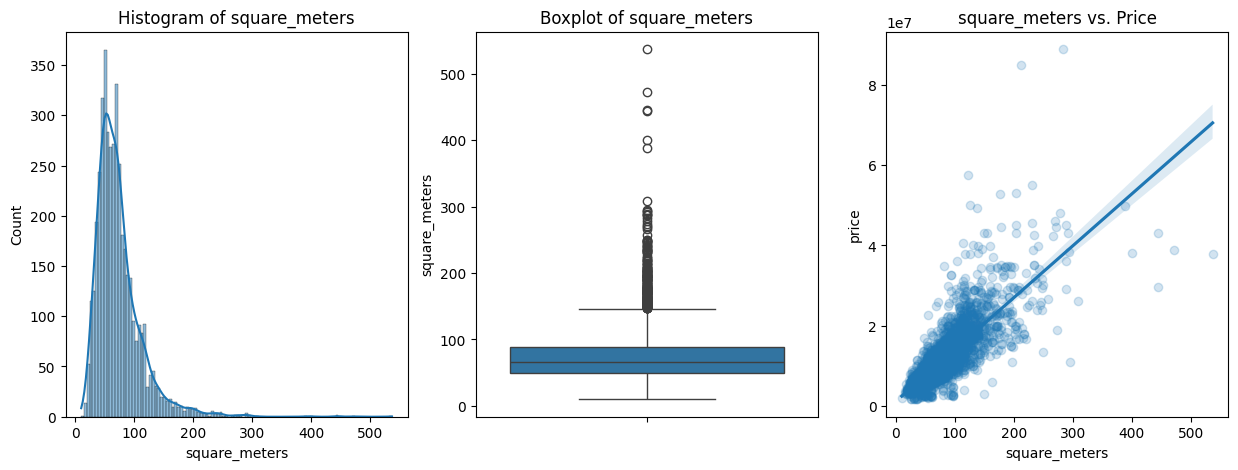

Feature: price_per_m2


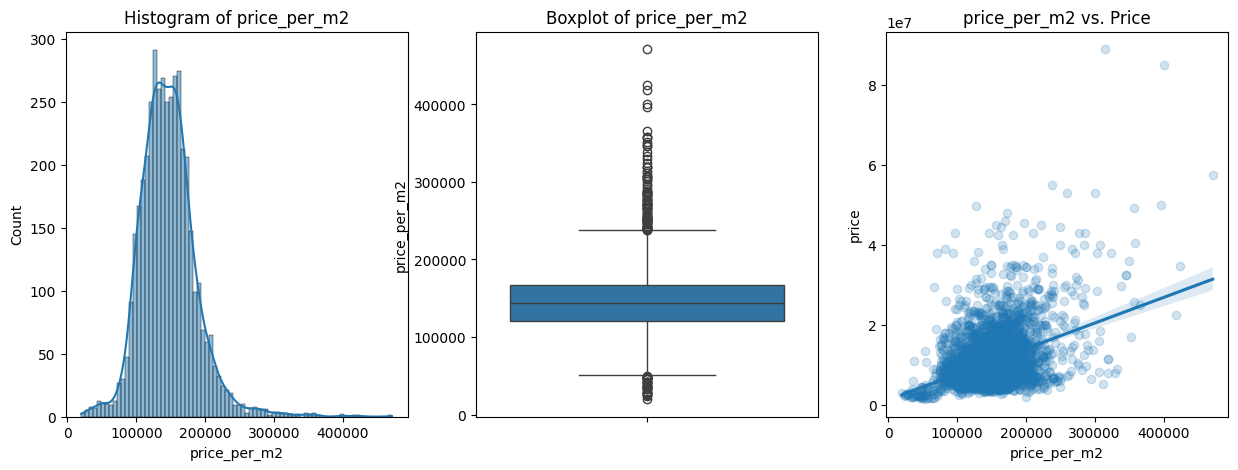

In [38]:
for var in continuous:
    print(f"Feature: {var}")
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))

    # histogram
    sns.histplot(data[var].dropna(), kde=True, ax=ax[0])
    ax[0].set_title(f"Histogram of {var}")

    # boxplot
    sns.boxplot(y=data[var], ax=ax[1])
    ax[1].set_title(f"Boxplot of {var}")

    # scatter plot with target variable
    sns.regplot(data=data, x=var, y=data['price'], scatter_kws={'alpha': 0.2}, ax=ax[2])
    ax[2].set_title(f"{var} vs. Price")

    plt.show()


Price is right skewed

- most properties are concentrated in the lower price range.
- consider log-transforming for linear regression

balcony, terrace, garden_area - mostly zeros
-  these act like binary plus magnitude features (0 = no feature, >0 = size).
-  outliers: A 50m² balcony, 1750m2 garden_area, 100m2 cellar, 200+ m2 terrace, final_building_approval_year = 31

square meters, floorage, usable area vs price
-  Distribution matches, strong candidates for predictive modeling

-  quite a lot of extreme values, consider log transformation or winsorization

3.2.3 Check for invalid values

In [39]:
# check for negative or zero values in columns that should be positive
for col in numerical:
    if (data[col] < 0).any():
        print(f"Negative values detected in {col}")


# check for outliers
def print_extreme_values(df, column, top=5):
    print(f"\n{column} - Highest Values:")
    print(df[column].sort_values(ascending=False).head(top))

for col in ['price', 'square_meters', 'balcony', 'terrace', 'cellar',
                     'garden_area', 'loggia']:
    print_extreme_values(data, col)


price - Highest Values:
4256    89000000.0
3914    85000000.0
1114    57500000.0
2794    54983500.0
1529    53000000.0
Name: price, dtype: float64

square_meters - Highest Values:
2653    537
2620    472
2494    445
4272    444
1863    400
Name: square_meters, dtype: int64

balcony - Highest Values:
1426    55
3783    36
4237    34
3729    33
662     31
Name: balcony, dtype: Int64

terrace - Highest Values:
267     220
2024    179
4085    164
2622    159
1047    151
Name: terrace, dtype: Int64

cellar - Highest Values:
2694    100
2812     50
1344     40
1581     37
4029     34
Name: cellar, dtype: Int64

garden_area - Highest Values:
943     1800
1581    1000
1896     949
729      883
2132     631
Name: garden_area, dtype: Int64

loggia - Highest Values:
3622    42
1188    31
1819    30
2274    20
735     20
Name: loggia, dtype: Int64


While some of the values look suspicious it's hard to tell if they are completely unrealistic.
- the garden that has area of 1800 m2 is definitely false, based on the street it's located on it seems that the garden is actually a public square.
- year 31 is also invalid

The values will be removed back in data cleansing notebook

Floor number should always be less or equal to total floors, other values are invalid and should be removed.

In [40]:
mask = (data['floor_number'] > data['total_floors']) & \
       data['floor_number'].notna() & data['total_floors'].notna()

n_invalid = mask.sum()
pct_invalid = n_invalid / len(data) * 100
print(f"{n_invalid} listings ({pct_invalid:.2f}%) have floor_number > total_floors.")

31 listings (0.72%) have floor_number > total_floors.


Checking future years (data was collected in 2024)

In [41]:
future_years = data[data['final_building_approval_year'] > 2024]
print(future_years['final_building_approval_year'].value_counts())

final_building_approval_year
2025    246
2026    213
2027     34
Name: count, dtype: Int64


All years that are later than the time of data collection seem reasonable and mean that the project approval date is expected in the nearest future, so no values should be dropped.

modelling notes from EDA:
- log transform price. distribution is right-skewed, log makes it near-normal
- use square_meters as the primary area variable. 0 missing values, high correlation with price. floorage and usable_area carry similar info
- use district over cadastral_area. cadastral_area is more granular but 100+ categories is problematic for linear models
- drop street. even higher cardinality, many categories have 1–2 observations
- remove cooperative flats. price doesn't reflect the full property value
- drop gas, water, heating, waste. low correlation with price and too much missing data
- group rare categories in building, property_status, property_location before encoding
- encode energy_performance_rating as ordinal integer. do this after split to avoid leakage
- floor_number and building_age likely useful. add is_top_floor / is_ground_floor flags
- binary area features (balcony, cellar, terrace etc.). mostly zeros, act as presence/absence flags